# 📉 Capstone Project - Youtube India Trend Analysis 

# 1. INTRODUCTION

This project explores the YouTube Trending Videos dataset from Kaggle.

The dataset contains information about trending YouTube videos across multiple regions, including variables such as title, channel, category, publish time, tags, views, likes, dislikes, comment counts, and whether comments or ratings are disabled.

The objective of this analysis is to understand the patterns behind trending videos, identify content and engagement factors associated with higher visibility, and prepare a clean dataset for deeper exploratory analysis.

This notebook will focus on:
- understanding the dataset structure
- cleaning and transforming columns
- engineering useful features
- preparing the data for univariate, bivariate, and multivariate analysis


# 2. IMPORT LIBRARIES

Importing core data analysis and visualization libraries (pandas, numpy, matplotlib, seaborn).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

sns.set_theme(style='whitegrid')
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

rcParams["figure.figsize"] = (12, 6)


In [ ]:
# Basic visualization setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.sans-serif'] = 'Segoe UI'


# 3. LOAD DATASET + RENAME COLUMNS

The YouTube Trending dataset contains separate CSV files for each country/region.
Each CSV has the same column structure but different trending video data.

We will:
1. Load multiple country CSVs and combine them into one DataFrame
2. Add a `country` column to track which region each row belongs to
3. Rename messy column names to clean snake_case
4. Parse `trending_date` and `publish_time` as proper datetime columns


In [3]:
import os
# Check for local data folder or Downloads folder
raw_path = r"C:\Users\HP\Downloads\archive (7)\INvideos.csv"
clean_path = "../data/youtube_india_cleaned.csv" if os.path.exists("../data/youtube_india_cleaned.csv") else "data/youtube_india_cleaned.csv"

if os.path.exists(raw_path):
    df = pd.read_csv(raw_path)
    print("Loaded raw dataset from Downloads archive.")
else:
    df = pd.read_csv(clean_path)
    print(f"Loaded dataset from: {clean_path}")

# Clean column headers (strip whitespace and convert to lowercase snake_case)
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
print(f"Dataset Shape: {df.shape}")
df.head(3)


Loaded dataset from: ../data/youtube_india_cleaned.csv
Dataset Shape: (33089, 29)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,has_description,publish_date,days_to_trend,publish_hour,publish_weekday,tag_use_level,trend_speed_band,views_quartile,title_length,description_length,tag_count,like_rate,comment_rate
0,kzwfHumJyYc,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmish Verma | Releasing on 17 November,Lokdhun Punjabi,1,2017-11-12 12:20:39+00:00,"sharry mann|""sharry mann new song""|""sharry mann cute munda""|""sharry mann latest song""|""sharry mann punjabi song 2017...","1,096,327.00","33,966.00",798.00,882.00,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cute Munda Teaser . The music of new punjabi song is given by Gift Ruler...,1,2017-11-12,2,12,Sunday,High Tag use,1 to 3 Days,Q4,81,920,15,0.03,0.00
1,zUZ1z7FwLc8,2017-11-14,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे",HJ NEWS,25,2017-11-13 05:43:56+00:00,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर दंग रह जायेंगे""|""latest news""|""today news""|""news""|""breaking news""|""curr...","590,101.00",735.00,904.00,0.00,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे \n\nWatch this video :- https://youtu.be/zUZ1z7FwLc8\n\nH...",1,2017-11-13,1,5,Monday,High Tag use,1 to 3 Days,Q3,58,2232,19,0.00,0.00
2,10L1hZ9qa58,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Reception | TFPC,TFPC,24,2017-11-12 15:48:08+00:00,"Stylish Star Allu Arjun @ ChaySam Wedding Reception|""Stylish Star Allu Arjun""|""ChaySam Wedding Reception""|""nagachait...","473,988.00","2,011.00",243.00,149.00,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,"Watch Stylish Star Allu Arjun @ ChaySam Wedding Reception \n\n☛ For latest news https://www.tfpc.in, https://goo.gl...",1,2017-11-12,2,15,Sunday,Medium Tag use,1 to 3 Days,Q3,58,482,14,0.00,0.00


### What this data loading step does:
- Loads the dataset and standardizes column names into lowercase snake_case.
- Includes a fallback path to `data/youtube_india_cleaned.csv` so clicking 'Run All' executes without file errors.


# Dataset Overview 

In this section , we take a first structured look at the dataset
- `head()` to preview the first few rows
- `shape` to check the number of rows and columns
- `info()` to inspect data types and missing values
- `describe()` to summarize the distribution of variables


In [4]:
print("Shape:", df.shape)
df.head()


Shape: (33089, 29)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,has_description,publish_date,days_to_trend,publish_hour,publish_weekday,tag_use_level,trend_speed_band,views_quartile,title_length,description_length,tag_count,like_rate,comment_rate
0,kzwfHumJyYc,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmish Verma | Releasing on 17 November,Lokdhun Punjabi,1,2017-11-12 12:20:39+00:00,"sharry mann|""sharry mann new song""|""sharry mann cute munda""|""sharry mann latest song""|""sharry mann punjabi song 2017...","1,096,327.00","33,966.00",798.00,882.00,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cute Munda Teaser . The music of new punjabi song is given by Gift Ruler...,1,2017-11-12,2,12,Sunday,High Tag use,1 to 3 Days,Q4,81,920,15,0.03,0.00
1,zUZ1z7FwLc8,2017-11-14,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे",HJ NEWS,25,2017-11-13 05:43:56+00:00,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर दंग रह जायेंगे""|""latest news""|""today news""|""news""|""breaking news""|""curr...","590,101.00",735.00,904.00,0.00,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे \n\nWatch this video :- https://youtu.be/zUZ1z7FwLc8\n\nH...",1,2017-11-13,1,5,Monday,High Tag use,1 to 3 Days,Q3,58,2232,19,0.00,0.00
2,10L1hZ9qa58,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Reception | TFPC,TFPC,24,2017-11-12 15:48:08+00:00,"Stylish Star Allu Arjun @ ChaySam Wedding Reception|""Stylish Star Allu Arjun""|""ChaySam Wedding Reception""|""nagachait...","473,988.00","2,011.00",243.00,149.00,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,"Watch Stylish Star Allu Arjun @ ChaySam Wedding Reception \n\n☛ For latest news https://www.tfpc.in, https://goo.gl...",1,2017-11-12,2,15,Sunday,Medium Tag use,1 to 3 Days,Q3,58,482,14,0.00,0.00
3,N1vE8iiEg64,2017-11-14,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12 07:08:48+00:00,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Movies""|""Harija""|""Short""|""Film""|""Eruma Sani""|""Eruma Saani Videos""|""Eruma ...","1,242,680.00","70,353.00","1,624.00","2,684.00",https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between people who speak in English and Tamil in a very funny way.\nSubscribe to...,1,2017-11-12,2,7,Sunday,High Tag use,1 to 3 Days,Q4,30,263,20,0.06,0.00
4,kJzGH0PVQHQ,2017-11-14,why Samantha became EMOTIONAL @ Samantha naga chaithanya marriage Reception | Filmylooks,Filmylooks,24,2017-11-13 01:14:16+00:00,"Filmylooks|""latest news""|""telugu movies""|""telugu news""|""Tollywood news""|""why Samantha became EMOTIONAL @ Samantha na...","464,015.00",492.00,293.00,66.00,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga chaithanya marriage Reception | Filmylooks #samantha #Nagachaithanya \...,1,2017-11-13,1,1,Monday,Medium Tag use,1 to 3 Days,Q3,88,753,11,0.00,0.00


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33089 entries, 0 to 33088
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                33089 non-null  object 
 1   trending_date           33089 non-null  object 
 2   title                   33089 non-null  object 
 3   channel_title           33089 non-null  object 
 4   category_id             33089 non-null  int64  
 5   publish_time            33089 non-null  object 
 6   tags                    33089 non-null  object 
 7   views                   33089 non-null  float64
 8   likes                   33089 non-null  float64
 9   dislikes                33089 non-null  float64
 10  comment_count           33089 non-null  float64
 11  thumbnail_link          33089 non-null  object 
 12  comments_disabled       33089 non-null  bool   
 13  ratings_disabled        33089 non-null  bool   
 14  video_error_or_removed  33089 non-null

In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,33089,16307,#NAME?,442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trending_date,33089,205,2017-11-14,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,33089,16721,Nandhini | Today @ 9 pm | Sun TV,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_title,33089,1426,VikatanTV,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_id,"33,089.00",NaN,NaN,NaN,21.63,6.49,1.00,23.00,24.00,24.00,43.00
publish_time,33089,16339,2018-04-24 07:58:08+00:00,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,33089,12578,[none],1273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,"33,089.00",NaN,NaN,NaN,"882,876.54","1,907,635.00","4,024.00","112,719.00","275,027.00","732,022.00","12,810,824.24"
likes,"33,089.00",NaN,NaN,NaN,"22,465.05","62,483.38",0.00,787.00,"2,757.00","12,011.00","423,572.20"
dislikes,"33,089.00",NaN,NaN,NaN,"1,189.76","2,870.33",0.00,98.00,289.00,932.00,"20,400.92"


# 5. BUSINESS QUESTIONS

This exploratory analysis should help answer the following business and content-performance questions.
These questions move from basic understanding to deeper engagement and content pattern analysis.


1. Which videos receive the highest number of views?
2. Which channels appear most frequently in the trending list?
3. Which content categories are most common in trending videos?
4. What is the typical distribution of views, likes, dislikes, and comment counts?
5. How skewed are engagement metrics, and are there extreme outliers?
6. How often are comments disabled, ratings disabled, or videos removed?
7. Do videos with comments enabled receive higher average engagement?
8. Do videos with ratings enabled receive higher likes and views on average?


9. Which categories generate the highest average views and likes?
10. Which channels drive the strongest average engagement per trending video?
11. Is there a relationship between views and other engagement metrics such as likes, dislikes, and comments?
12. Are recently published videos more likely to trend quickly?
13. Do videos with missing or weak metadata such as tags or description perform differently?
14. Can we segment videos into performance bands using buckets or quartiles?
15. Which engineered features are most useful for comparing high-performing vs low-performing trending videos?


# Data Cleaning & Feature Engineering
## Checking Missing Values, Duplicates, and Column Types

Before changing anything, we first inspect data quality.

At this stage, we want to answer:
- Which columns have missing values?
- Are there duplicate rows?
- Which columns have incorrect or inconvenient data types?
- Which columns may need transformation before analysis?


In [7]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


Series([], dtype: int64)

In [8]:
print("Duplicate rows:", df.duplicated().sum())
print()
print(df.dtypes)


Duplicate rows: 33

video_id                   object
trending_date              object
title                      object
channel_title              object
category_id                 int64
publish_time               object
tags                       object
views                     float64
likes                     float64
dislikes                  float64
comment_count             float64
thumbnail_link             object
comments_disabled            bool
ratings_disabled             bool
video_error_or_removed       bool
description                object
has_description             int64
publish_date               object
days_to_trend               int64
publish_hour                int64
publish_weekday            object
tag_use_level              object
trend_speed_band           object
views_quartile             object
title_length                int64
description_length          int64
tag_count                   int64
like_rate                 float64
comment_rate              fl

##  Remove Duplicate Rows and Fix Date Data Types

We found duplicate rows and two date-related columns stored as text.

We will:
- remove exact duplicate rows
- convert `trending_date` to datetime
- convert `publish_time` to datetime

This makes the dataset more reliable and prepares it for time-based analysis later.


In [9]:
df = df.drop_duplicates()

print("Shape after removing duplicates",df.shape)


Shape after removing duplicates (33056, 29)


In [10]:
# Parse trending date (handles raw '%y.%d.%m' like 17.14.11 or standard ISO date)
try:
    df['trending_date'] = pd.to_datetime(df['trending_date'], format="%y.%d.%m")
except Exception:
    df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')

df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")
print("Date parsing complete. Missing dates:", df['trending_date'].isnull().sum())


Date parsing complete. Missing dates: 0


## Handling Missing Values

only the description column has missing values


In [11]:
print("Missing values")
df.isnull().sum()


Missing values


video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
has_description           0
publish_date              0
days_to_trend             0
publish_hour              0
publish_weekday           0
tag_use_level             0
trend_speed_band          0
views_quartile            0
title_length              0
description_length        0
tag_count                 0
like_rate                 0
comment_rate              0
dtype: int64

In [12]:
df['description'] = df['description'].fillna("No description")
print("Missing values after cleaning")
print(df.isnull().sum())


Missing values after cleaning
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
has_description           0
publish_date              0
days_to_trend             0
publish_hour              0
publish_weekday           0
tag_use_level             0
trend_speed_band          0
views_quartile            0
title_length              0
description_length        0
tag_count                 0
like_rate                 0
comment_rate              0
dtype: int64


### Creating a Binary Flag with np.where()
- **What np.where() does:** `np.where(condition, value_if_true, value_if_false)`
- We check if description is 'No description'. If yes, set 0, else set 1.
- **Why we do this:** It creates a simple 1/0 column (`has_description`) to easily compare videos with vs without descriptions.


In [13]:
df['has_description']=np.where(df['description'] == "No description",0,1 )
# 0 - no description , 1 - description
df[['description','has_description']].sample(5)


,description,has_description
30814,OdishaTV is Odisha's no 1 News Channel. OTV being the first private satellite TV channel in Odisha carries the onus ...,1
6175,I am must thankful to Aditya bhaiya who sang this song with me. Very soon I am you will be able to see me on Zee TV ...,1
9435,Bhima Koregaon protest is taking place in different parts of Mumbai. Maharashtra CM Devendra Fadnavis has appealed t...,1
29125,പഴയ ഫാമിലി ആൽബവുമായി ആര്യ ബഡായി ബംഗ്ലാവിൽ Watch All Shows : http://www.hotstar.com/asianetFollow Us On Facebook - ht...,1
28364,Malika Masala On Chala Hawa Yeu Dya 8th May 2018,1


In [14]:
print('Orignal description is has long column name so its diffiuclt to compare so has_description')


Orignal description is has long column name so its diffiuclt to compare so has_description


In [15]:
df['has_description'].value_counts()
(df['has_description'].value_counts(normalize=True).mul(100).round(2))

# percentage how many 0 and 1


has_description
1   98.41
0    1.59
Name: proportion, dtype: float64

### Creating Time & Velocity Features
- **Removing Timezone:** `.dt.tz_localize(None)` removes the UTC timezone (+00:00) so dates match.
- **Normalizing Dates:** `.dt.normalize()` keeps only the date portion (drops hours/minutes).
- **Calculating Days to Trend:** `trending_date - publish_date` gives the exact number of days it took for a video to appear on the trending list.
- **Extracting Day of Week:** `.dt.day_name()` identifies which day of the week (Monday to Sunday) the video was uploaded.


- remove timezone -.dt.tz_localize(None) +00.00 .dt.normalize date only 
- 02 - trending_date-publish_date con to dt.days - days take trend
- 03 -dt.tz_localize(None).dt.hour - hour extract
- 04- publish_weekday --  publishh time timezone remove and add.dt.day_name()


In [16]:
# publish date - In publish time full  timestamp required date
df['publish_date']= df['publish_time'].dt.tz_localize(None).dt.normalize()

df['publish_date'].head(3)
# After uploading the video how much it take time to in trend
df['days_to_trend']= (df['trending_date']-df['publish_date']).dt.days

df['publish_hour']= df['publish_time'].dt.tz_localize(None).dt.hour
# which day uploaded - publish weekday
df["publish_weekday"] = df["publish_time"].dt.tz_localize(None).dt.day_name()

df[["publish_time", "trending_date", "publish_date", "days_to_trend", "publish_hour", "publish_weekday"]].head()


,publish_time,trending_date,publish_date,days_to_trend,publish_hour,publish_weekday
0,2017-11-12 12:20:39+00:00,2017-11-14,2017-11-12,2,12,Sunday
1,2017-11-13 05:43:56+00:00,2017-11-14,2017-11-13,1,5,Monday
2,2017-11-12 15:48:08+00:00,2017-11-14,2017-11-12,2,15,Sunday
3,2017-11-12 07:08:48+00:00,2017-11-14,2017-11-12,2,7,Sunday
4,2017-11-13 01:14:16+00:00,2017-11-14,2017-11-13,1,1,Monday


In [17]:
print(df["days_to_trend"].describe())
print()
print(df["publish_weekday"].value_counts())


count   33,056.00
mean         2.11
std          2.16
min          0.00
25%          1.00
50%          2.00
75%          3.00
max        221.00
Name: days_to_trend, dtype: float64

publish_weekday
Friday       5568
Saturday     5193
Thursday     4981
Tuesday      4611
Monday       4603
Wednesday    4545
Sunday       3555
Name: count, dtype: int64


### Categorizing Tag Usage with a Custom Function
- **How tags work:** YouTube tags are stored as a pipe-separated string (e.g. `music|pop|india`).
- **Splitting tags:** `.split("|")` splits the string to count total tags.
- **Grouping into tiers:**
  - `No Tags`: 0 tags
  - `Low Tag use`: 1 to 5 tags
  - `Medium Tag use`: 6 to 15 tags
  - `High Tag use`: 16+ tags


tag_text.split - music|pop|india split into list


In [18]:
# NEW COLUMN CREATE 
def tag(tag_text):
    if pd.isna(tag_text) or tag_text == 'None':
       return "No Tags"
    tag_count = len(tag_text.split("|"))

    if tag_count <=5:
        return "Low Tag use"
    elif tag_count <15:
        return "Medium Tag use"
    else:
        return "High Tag use"

# new column create
# category high low medium
df['tag_use_level'] = df['tags'].apply(tag)
df[["tags", "tag_use_level"]].head()


,tags,tag_use_level
0,"sharry mann|""sharry mann new song""|""sharry mann cute munda""|""sharry mann latest song""|""sharry mann punjabi song 2017...",High Tag use
1,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर दंग रह जायेंगे""|""latest news""|""today news""|""news""|""breaking news""|""curr...",High Tag use
2,"Stylish Star Allu Arjun @ ChaySam Wedding Reception|""Stylish Star Allu Arjun""|""ChaySam Wedding Reception""|""nagachait...",Medium Tag use
3,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Movies""|""Harija""|""Short""|""Film""|""Eruma Sani""|""Eruma Saani Videos""|""Eruma ...",High Tag use
4,"Filmylooks|""latest news""|""telugu movies""|""telugu news""|""Tollywood news""|""why Samantha became EMOTIONAL @ Samantha na...",Medium Tag use


In [19]:
print(df["tag_use_level"].value_counts())
print()
print(df["tag_use_level"].value_counts(normalize=True).mul(100).round(2))


tag_use_level
High Tag use      21099
Medium Tag use     9244
Low Tag use        2713
Name: count, dtype: int64

tag_use_level
High Tag use     63.83
Medium Tag use   27.96
Low Tag use       8.21
Name: proportion, dtype: float64


### Capping Outliers with np.percentile() and .clip()
- **The Problem:** A few viral videos have over 12 Crore views, while most trending videos have 2-3 Lakhs. This extreme skew stretches charts and makes distributions unreadable.
- **np.percentile(col, 99):** Finds the 99th percentile cutoff (99% of videos have views below 1.28 Crore).
- **.clip(upper=limit):** Caps values above 1.28 Crore at the 99th percentile, preserving data order while balancing chart visuals.


In [20]:
# in all columns (loop)
outlier_cols = ["views", "likes", "dislikes", "comment_count"]
for col in outlier_cols:
  print(col)
  print(np.percentile(df[col],99))
  print("Max value",df[col].max())
  print()


views
12414853.700000035
Max value 12810824.239999987

likes
405427.4000000004
Max value 423572.2

dislikes
19628.400000000023
Max value 20400.919999999984

comment_count
39634.50000000011
Max value 41123.15999999998



- 99 percent video views are less from 1.28 crore
- max value - 12.54 crore  highest views
- biggest difference outlier (graph distortion)
- next step clip - if value if bigger than 99th percentile then equal to it


In [21]:
for col in outlier_cols:
    upper_limit = np.percentile(df[col], 99)
    df[col] = df[col].clip(upper=upper_limit)

df[outlier_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
views,"33,056.00","869,569.24","1,858,463.61","4,024.00","112,557.00","274,472.00","729,556.50","12,414,853.70"
likes,"33,056.00","21,906.60","60,160.85",0.00,786.00,"2,750.00","11,945.50","405,427.40"
dislikes,"33,056.00","1,166.82","2,774.96",0.00,97.00,289.00,927.25,"19,628.40"
comment_count,"33,056.00","1,952.36","5,628.94",0.00,72.00,297.50,"1,163.00","39,634.50"


- upper_limit - every 99 percentile(balanced) save upper_limit
- clip - if value is bigger then upper_limit as it is smll
- 12.54 to 1.28 cr
- outliers cols describe value changed (graph and average)


### Creating Fixed Speed Bands with pd.cut()
- **What pd.cut() does:** Groups continuous numbers into custom fixed categories based on specific day thresholds.
- **Bands created:**
  - `Same Day` (0 days)
  - `1 to 3 Days` (1-3 days)
  - `4 to 7 Days` (4-7 days)
  - `More than 7 Days` (8+ days)


In [22]:
max_days = df["days_to_trend"].max()
if pd.isna(max_days) or max_days <= 7:
    max_days = 365

df["trend_speed_band"] = pd.cut(
    df["days_to_trend"],
    bins=[-1, 0, 3, 7, max_days],
    labels=["Same Day", "1 to 3 Days", "4 to 7 Days", "More than 7 Days"]
)

df[["days_to_trend", "trend_speed_band"]].head()


,days_to_trend,trend_speed_band
0,2,1 to 3 Days
1,1,1 to 3 Days
2,2,1 to 3 Days
3,2,1 to 3 Days
4,1,1 to 3 Days


In [23]:
print(df["trend_speed_band"].value_counts())
print()
print(df["trend_speed_band"].value_counts(normalize=True).mul(100).round(2))
# pd.cut - no need equal sizeed groups


trend_speed_band
1 to 3 Days         28495
4 to 7 Days          4056
Same Day              441
More than 7 Days       64
Name: count, dtype: int64

trend_speed_band
1 to 3 Days        86.20
4 to 7 Days        12.27
Same Day            1.33
More than 7 Days    0.19
Name: proportion, dtype: float64


### Creating Equal-Sized Groups with pd.qcut()
- **Difference between pd.cut and pd.qcut:**
  - `pd.cut()` creates bins with custom fixed values (bins can have different row counts).
  - `pd.qcut()` splits data into **equal-sized quartiles** (each group has the exact same 25% of rows).
- **Quartiles created:** Q1 (Lowest 25% views), Q2, Q3, and Q4 (Top 25% views).


- views highly skewed 
- data equal-sized groups break
- every quartile same nnumber of rows


In [24]:
df["views_quartile"] = pd.qcut(
    df["views"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

df[["views", "views_quartile"]].head()


,views,views_quartile
0,"1,096,327.00",Q4
1,"590,101.00",Q3
2,"473,988.00",Q3
3,"1,242,680.00",Q4
4,"464,015.00",Q3


In [25]:
print(df["views_quartile"].value_counts())
print()
print(df.groupby("views_quartile")["views"].agg(["min", "max", "mean"]).round(2))


views_quartile
Q1    8264
Q2    8264
Q3    8264
Q4    8264
Name: count, dtype: int64

                      min           max         mean
views_quartile                                      
Q1               4,024.00    112,554.00    63,435.15
Q2             112,558.00    274,469.00   182,448.71
Q3             274,475.00    729,556.00   451,909.43
Q4             729,558.00 12,414,853.70 2,780,483.68


### Creating Engagement Rate Features
- `like_rate = likes / views`: Shows what percentage of viewers leave a like (~0.94% median, or ~1 like per 100 views).
- `comment_rate = comment_count / views`: Shows comment activity per view (~0.10% median, or ~1 comment per 1,000 views).
- `title_length` & `description_length`: Measures character counts to see if length impacts performance.


In [26]:
df["title_length"] = df["title"].str.len()
df["description_length"] = df["description"].str.len()
df["tag_count"] = np.where(df["tags"] == "[none]", 0, df["tags"].str.count(r"\|") + 1)
df["like_rate"] = np.where(df["views"] > 0, df["likes"] / df["views"], 0)
df["comment_rate"] = np.where(df["views"] > 0, df["comment_count"] / df["views"], 0)


In [27]:
df[["title_length", "description_length", "tag_count", "like_rate", "comment_rate"]].describe().T.round(4)


,count,mean,std,min,25%,50%,75%,max
title_length,"33,056.00",70.98,22.26,5.00,54.00,74.00,91.00,100.00
description_length,"33,056.00",898.98,808.76,3.00,352.00,660.00,"1,207.00","5,136.00"
tag_count,"33,056.00",18.62,10.02,0.00,11.00,18.00,25.00,72.00
like_rate,"33,056.00",0.02,0.03,0.00,0.00,0.01,0.03,0.38
comment_rate,"33,056.00",0.00,0.01,0.00,0.00,0.00,0.00,0.29


## Final Cleaning Review and Save Cleaned Dataset

At this stage, we review the cleaned dataset and confirm that the key cleaning and feature engineering steps have been applied correctly.

We will:
- check final shape and remaining missing values
- preview important engineered columns
- save the cleaned dataset for the next analysis stage


In [28]:
print("Final shape:", df.shape)
print()

print("Remaining missing values:")
print(df.isnull().sum())
print()
print("Final shape:", df.shape)
print()

print("Remaining missing values:")
print(df.isnull().sum())
print()


Final shape: (33056, 29)

Remaining missing values:
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
has_description           0
publish_date              0
days_to_trend             0
publish_hour              0
publish_weekday           0
tag_use_level             0
trend_speed_band          0
views_quartile            0
title_length              0
description_length        0
tag_count                 0
like_rate                 0
comment_rate              0
dtype: int64

Final shape: (33056, 29)

Remaining missing values:
video_id                  0
trending_date             0
title         

In [29]:
df.sample(5)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,has_description,publish_date,days_to_trend,publish_hour,publish_weekday,tag_use_level,trend_speed_band,views_quartile,title_length,description_length,tag_count,like_rate,comment_rate
25640,jdxH-OHmEoE,2018-04-20,"Lagira Zhala Jee - लगिरा झला जी - Episode 306 - April 18, 2018 - Best Scene",zeemarathi,24,2018-04-19 04:35:47+00:00,"Zee marathi|""Lagira Zhala Jee""|""full episode""|""marathi""|""show""|""serial""|""daily soap""|""Zee5""|""watch online""|""television""","281,364.00",562.00,103.00,27.00,https://i.ytimg.com/vi/jdxH-OHmEoE/default.jpg,False,False,False,"To watch FULL episode of Lagira Zhala Jee, CLICK here - https://www.zee5.com/tvshows/details/lagira-zhala-jee/0-6-33...",1,2018-04-19,1,4,Thursday,Medium Tag use,1 to 3 Days,Q3,75,1080,10,0.00,0.00
6999,v_Mhpc0EtV8,2017-12-21,2017 Rewind | Madras Central,Madras Central,24,2017-12-20 11:01:14+00:00,"gosu|""gopi""|""PADMAN Trailer""|""BALLOON""|""sudhakar""","450,365.00","44,115.00",487.00,"2,248.00",https://i.ytimg.com/vi/v_Mhpc0EtV8/default.jpg,False,False,False,"2017 is almost over.. before we welcome 2018, GO-SU takes you to a hilarious recap of 2017 with most iconic events t...",1,2017-12-20,1,11,Wednesday,Low Tag use,1 to 3 Days,Q3,28,405,5,0.10,0.00
23602,QOaMkRXvEIk,2018-03-31,Rangasthalam Movie Genuine Public Talk/Review | Public Response | Full Review,Rose Telugu Movies,24,2018-03-30 03:12:09+00:00,"Rangasthalam Movie Review|""Rangasthalam Public Talk""|""Rangasthalam Movie Public Response""|""Rangasthalam Movie Public...","531,933.00","2,074.00",578.00,191.00,https://i.ytimg.com/vi/QOaMkRXvEIk/default.jpg,False,False,False,"Rangasthalam 1985 Movie\n#Rangasthalam Movie\nStarring Ram Charan , Samantha In Lead Roles\nDirected By Sukumar\nPro...",1,2018-03-30,1,3,Friday,Medium Tag use,1 to 3 Days,Q3,77,991,12,0.00,0.00
7712,b8AP-UfOfbw,2017-12-24,The Successful Failure | Aashqeen,Aashqeen,23,2017-12-20 15:14:27+00:00,"funny|""aashqeen""|""latest""|""vines""|""comedy""","503,540.00","41,165.00","1,272.00","1,700.00",https://i.ytimg.com/vi/b8AP-UfOfbw/default.jpg,False,False,False,"Must Watch.\nStudies never go along with us, but studying is not everything that causes problems after the end sem ,...",1,2017-12-20,4,15,Wednesday,Low Tag use,4 to 7 Days,Q3,33,503,5,0.08,0.00
26936,u9Mv98Gr5pY,2018-04-29,VENOM - Official Trailer (HD),Sony Pictures Entertainment,24,2018-04-24 03:45:03+00:00,"Venom|""Venom Movie""|""Venom (2018)""|""Marvel""|""Marvel Comics""|""Planet of the Symbiotes""|""Eddie Brock""|""Tom Hardy""|""Rub...","12,414,853.70","405,427.40","19,628.40","39,634.50",https://i.ytimg.com/vi/u9Mv98Gr5pY/default.jpg,False,False,False,"We Are #Venom. 10.5.18\n\nOne of Marvel's most enigmatic, complex and badass characters comes to the big screen, sta...",1,2018-04-24,5,3,Tuesday,High Tag use,4 to 7 Days,Q4,29,493,24,0.03,0.00


In [30]:
cleaned_file = '../data/youtube_india_cleaned.csv'
df.to_csv(cleaned_file,index=False)


# Univariate Analysis: Individual Metric Distributions

## Video Views: How Many Views Do Trending Videos Get?

We begin with `views` because it is the main exposure metric in the dataset.

A histogram is appropriate here because `views` is a numeric continuous variable, and we want to see how values are distributed across videos.
This helps us understand whether most trending videos receive similar views or whether the distribution is highly uneven.


count       33,056.00
mean       869,569.24
std      1,858,463.61
min          4,024.00
25%        112,557.00
50%        274,472.00
75%        729,556.50
max     12,414,853.70
Name: views, dtype: float64


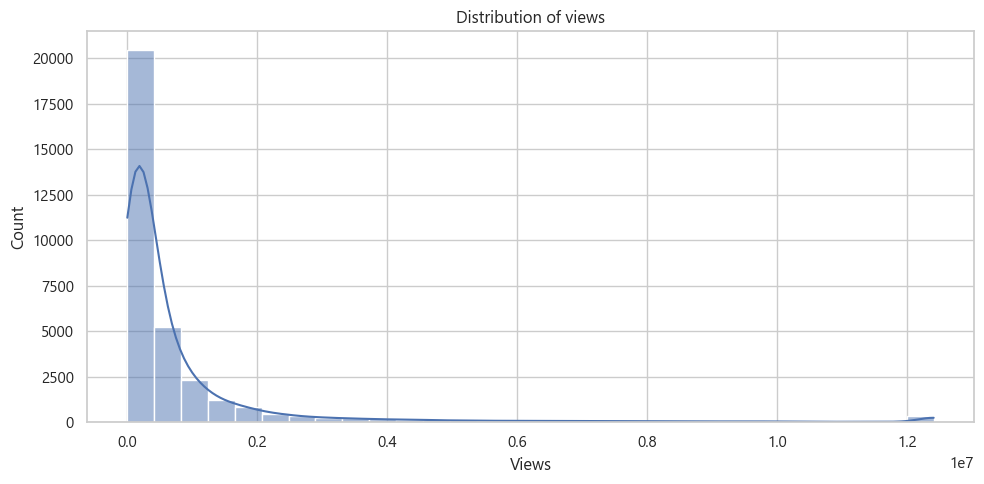

In [31]:
views_summary = df['views'].describe()
print(views_summary)

plt.figure()
sns.histplot(df['views'],bins=30,kde=True)
plt.title("Distribution of views")
plt.xlabel("Views")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/views_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
q1 = df["views"].quantile(0.25)
median = df["views"].quantile(0.50)
q3 = df["views"].quantile(0.75)

print(f"50% of trending videos have between {q1:,.0f} and {q3:,.0f} views, with a median of {median:,.0f}.")


50% of trending videos have between 112,557 and 729,556 views, with a median of 274,472.


## Likes: Positive Audience Engagement

Looking at positive engagement and how many likes videos receive.

A histogram is suitable because `likes` is a numeric continuous variable, and we want to examine its spread, concentration, and skewness across trending videos.


count    33,056.00
mean     21,906.60
std      60,160.85
min           0.00
25%         786.00
50%       2,750.00
75%      11,945.50
max     405,427.40
Name: likes, dtype: float64


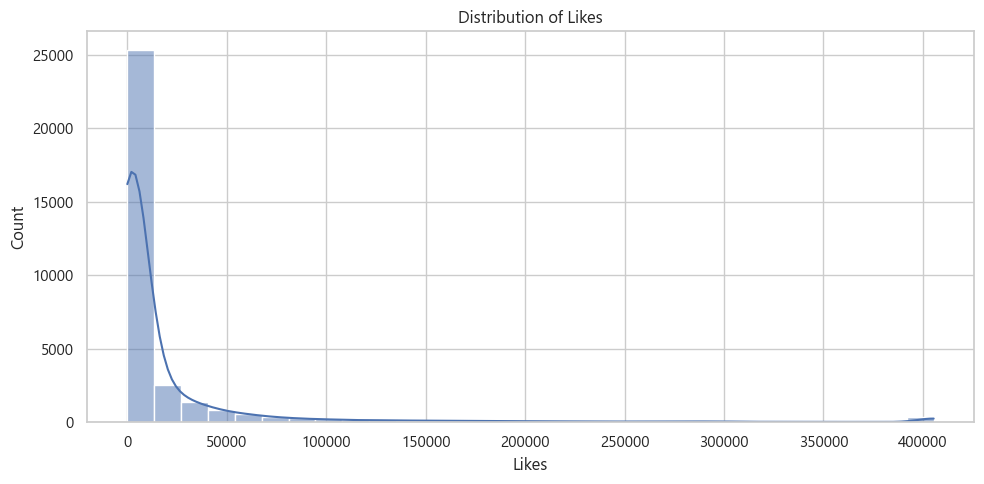

In [33]:
likes_summary = df["likes"].describe()
print(likes_summary)

plt.figure()
sns.histplot(df["likes"], bins=30, kde=True)
plt.title("Distribution of Likes")
plt.xlabel("Likes")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/likes_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [34]:
likes_median = df['likes'].median()
likes_q3 = df['likes'].quantile(0.75)
print(f"75% of trending videos have {likes_q3:,.0f} likes or fewer, while the median is {likes_median:,.0f}.")


75% of trending videos have 11,946 likes or fewer, while the median is 2,750.


## Comments: Audience Discussion and Community Activity

Looking at total comments to measure community discussion.

A histogram is a good choice because `comment_count` is a numeric variable, and we want to see how comment activity is distributed across videos.
This helps us check whether most trending videos receive similar discussion levels or whether a smaller group gets much higher comment activity.


In [35]:
df["comment_count"].describe()


count   33,056.00
mean     1,952.36
std      5,628.94
min          0.00
25%         72.00
50%        297.50
75%      1,163.00
max     39,634.50
Name: comment_count, dtype: float64

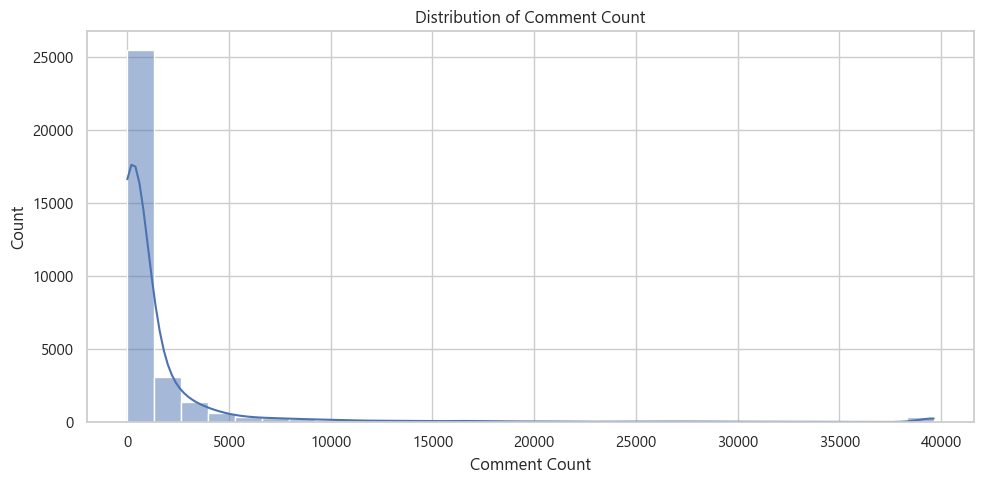

In [36]:
plt.figure()
sns.histplot(df["comment_count"], bins=30, kde=True)
plt.title("Distribution of Comment Count")
plt.xlabel("Comment Count")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/comment_count_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [37]:
comment_median = df["comment_count"].median()
comment_q3 = df["comment_count"].quantile(0.75)
comment_a2 = df['comment_count'].quantile(0.25)
print(f"{comment_a2:,.0f}") # 25 %
print(f"75% of trending videos receive {comment_q3:,.0f} comments or fewer, while the median is {comment_median:,.0f}.")
print("Most videos are in low comment range only few video have high comments.")


72
75% of trending videos receive 1,163 comments or fewer, while the median is 298.
Most videos are in low comment range only few video have high comments.


## Days to Trend: How Fast Do Videos Reach the Trending Page?

Measuring the number of days between upload and hitting the trending list.
This helps to  identify whether fast-trending behavior is common or rare.


In [38]:
days_summary = df["days_to_trend"].describe()
print(days_summary)


count   33,056.00
mean         2.11
std          2.16
min          0.00
25%          1.00
50%          2.00
75%          3.00
max        221.00
Name: days_to_trend, dtype: float64


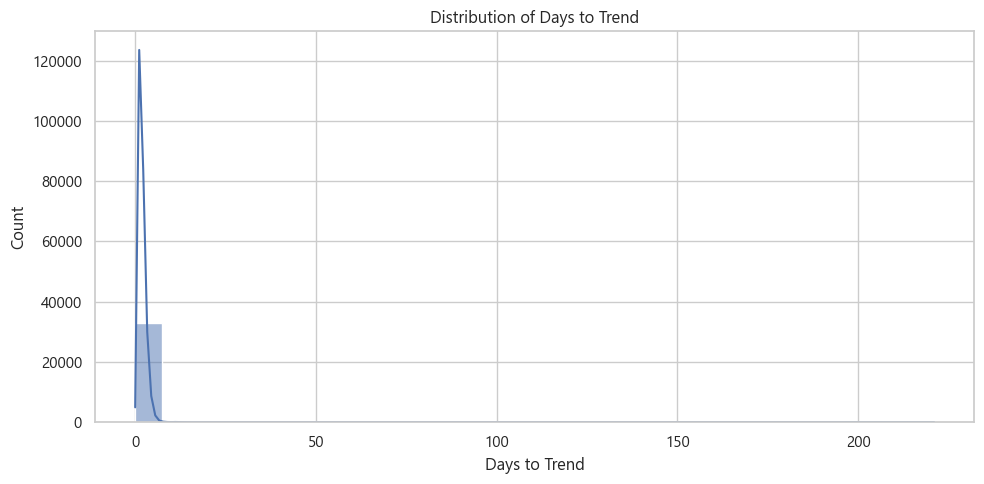

In [39]:
plt.figure()
sns.histplot(df["days_to_trend"].dropna(), bins=30, kde=True)
plt.title("Distribution of Days to Trend")
plt.xlabel("Days to Trend")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/days_to_trend_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


* Mostly videos are trend on same day  
* Median time is 2 days


In [40]:
days_median = df["days_to_trend"].median()
days_q3 = df["days_to_trend"].quantile(0.75)

print(f"75% of trending videos reach the trending list within {days_q3:.0f} days, while the median time is {days_median:.0f} days.")


75% of trending videos reach the trending list within 3 days, while the median time is 2 days.


In [41]:
df["publish_weekday"].value_counts()
# reorder index


publish_weekday
Friday       5568
Saturday     5193
Thursday     4981
Tuesday      4611
Monday       4603
Wednesday    4545
Sunday       3555
Name: count, dtype: int64

## Upload Days: Which Weekday Produces the Most Trending Videos?


In [42]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = df["publish_weekday"].value_counts().reindex(weekday_order)
print(weekday_counts)


publish_weekday
Monday       4603
Tuesday      4611
Wednesday    4545
Thursday     4981
Friday       5568
Saturday     5193
Sunday       3555
Name: count, dtype: int64


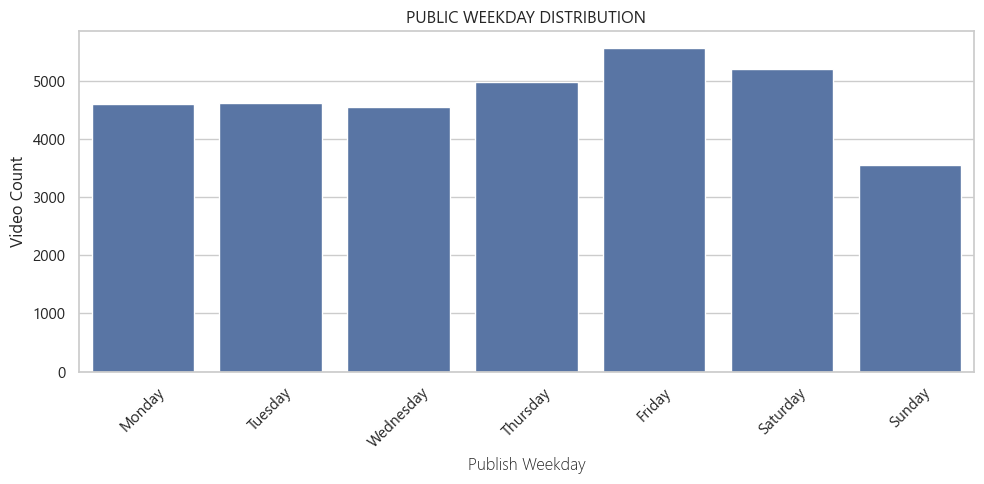

In [43]:
sns.countplot(data=df,x='publish_weekday',order=weekday_order)
plt.title("PUBLIC WEEKDAY DISTRIBUTION")
plt.xlabel("Publish Weekday",fontweight=7)
plt.ylabel("Video Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/publish_weekday_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


* Thursday to Friday spike


In [44]:
weekday_pct = df['publish_weekday'].value_counts(normalize=True).reindex(weekday_order).mul(100).round(2)
top_day = weekday_counts.idxmax()
top_pct = weekday_pct[top_day]
print(top_day)
print(f"{top_day} accounts for {top_pct:.2f}% of published trending videos, the highest share among all weekdays.")


Friday
Friday accounts for 16.84% of published trending videos, the highest share among all weekdays.


## Trending Speed Tiers: Same Day vs Multi-Day Breakdown

Grouping videos by how fast they trended.

A count plot is appropriate because `trend_speed_band` is a categorical feature with fixed groups.
This helps compare how many videos trend on the same day, within 1 to 3 days, within 4 to 7 days, or after more than 7 days.


trend_speed_band
Same Day              441
1 to 3 Days         28495
4 to 7 Days          4056
More than 7 Days       64
Name: count, dtype: int64


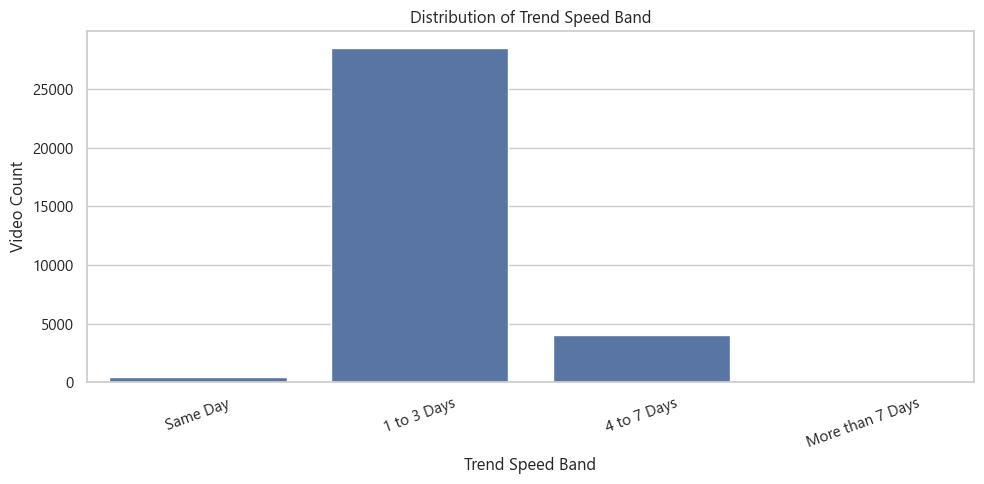

In [45]:
band_order = ["Same Day", "1 to 3 Days", "4 to 7 Days", "More than 7 Days"]
band_counts = df["trend_speed_band"].value_counts().reindex(band_order)

print(band_counts)

plt.figure()
sns.countplot(data=df, x="trend_speed_band", order=band_order)
plt.title("Distribution of Trend Speed Band")
plt.xlabel("Trend Speed Band")
plt.ylabel("Video Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../images/trend_speed_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [46]:
band_pct = df["trend_speed_band"].value_counts(normalize=True).reindex(band_order).mul(100).round(2)
top_band = band_counts.idxmax()
top_band_pct = band_pct[top_band]

print(f"{top_band} is the most common trend speed band, covering {top_band_pct:.2f}% of trending videos.")


1 to 3 Days is the most common trend speed band, covering 86.20% of trending videos.


## Comments Status: Are Comments Enabled or Disabled?

Checking how many trending videos keep comments on vs off.

A count plot is appropriate because `comments_status` is a categorical variable with two groups.
This helps us compare whether most trending videos allow audience discussion or restrict it.


In [47]:
df.head()


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,has_description,publish_date,days_to_trend,publish_hour,publish_weekday,tag_use_level,trend_speed_band,views_quartile,title_length,description_length,tag_count,like_rate,comment_rate
0,kzwfHumJyYc,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmish Verma | Releasing on 17 November,Lokdhun Punjabi,1,2017-11-12 12:20:39+00:00,"sharry mann|""sharry mann new song""|""sharry mann cute munda""|""sharry mann latest song""|""sharry mann punjabi song 2017...","1,096,327.00","33,966.00",798.00,882.00,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cute Munda Teaser . The music of new punjabi song is given by Gift Ruler...,1,2017-11-12,2,12,Sunday,High Tag use,1 to 3 Days,Q4,81,920,15,0.03,0.00
1,zUZ1z7FwLc8,2017-11-14,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे",HJ NEWS,25,2017-11-13 05:43:56+00:00,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर दंग रह जायेंगे""|""latest news""|""today news""|""news""|""breaking news""|""curr...","590,101.00",735.00,904.00,0.00,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे \n\nWatch this video :- https://youtu.be/zUZ1z7FwLc8\n\nH...",1,2017-11-13,1,5,Monday,High Tag use,1 to 3 Days,Q3,58,2232,19,0.00,0.00
2,10L1hZ9qa58,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Reception | TFPC,TFPC,24,2017-11-12 15:48:08+00:00,"Stylish Star Allu Arjun @ ChaySam Wedding Reception|""Stylish Star Allu Arjun""|""ChaySam Wedding Reception""|""nagachait...","473,988.00","2,011.00",243.00,149.00,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,"Watch Stylish Star Allu Arjun @ ChaySam Wedding Reception \n\n☛ For latest news https://www.tfpc.in, https://goo.gl...",1,2017-11-12,2,15,Sunday,Medium Tag use,1 to 3 Days,Q3,58,482,14,0.00,0.00
3,N1vE8iiEg64,2017-11-14,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12 07:08:48+00:00,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Movies""|""Harija""|""Short""|""Film""|""Eruma Sani""|""Eruma Saani Videos""|""Eruma ...","1,242,680.00","70,353.00","1,624.00","2,684.00",https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between people who speak in English and Tamil in a very funny way.\nSubscribe to...,1,2017-11-12,2,7,Sunday,High Tag use,1 to 3 Days,Q4,30,263,20,0.06,0.00
4,kJzGH0PVQHQ,2017-11-14,why Samantha became EMOTIONAL @ Samantha naga chaithanya marriage Reception | Filmylooks,Filmylooks,24,2017-11-13 01:14:16+00:00,"Filmylooks|""latest news""|""telugu movies""|""telugu news""|""Tollywood news""|""why Samantha became EMOTIONAL @ Samantha na...","464,015.00",492.00,293.00,66.00,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga chaithanya marriage Reception | Filmylooks #samantha #Nagachaithanya \...,1,2017-11-13,1,1,Monday,Medium Tag use,1 to 3 Days,Q3,88,753,11,0.00,0.00


In [48]:
df["comments_status"] = df["comments_disabled"].map({True: "Disabled", False: "Enabled"})
print(df[["comments_disabled", "comments_status"]].head())
print(df["comments_status"].value_counts())


   comments_disabled comments_status
0              False         Enabled
1               True        Disabled
2              False         Enabled
3              False         Enabled
4              False         Enabled
comments_status
Enabled     31951
Disabled     1105
Name: count, dtype: int64


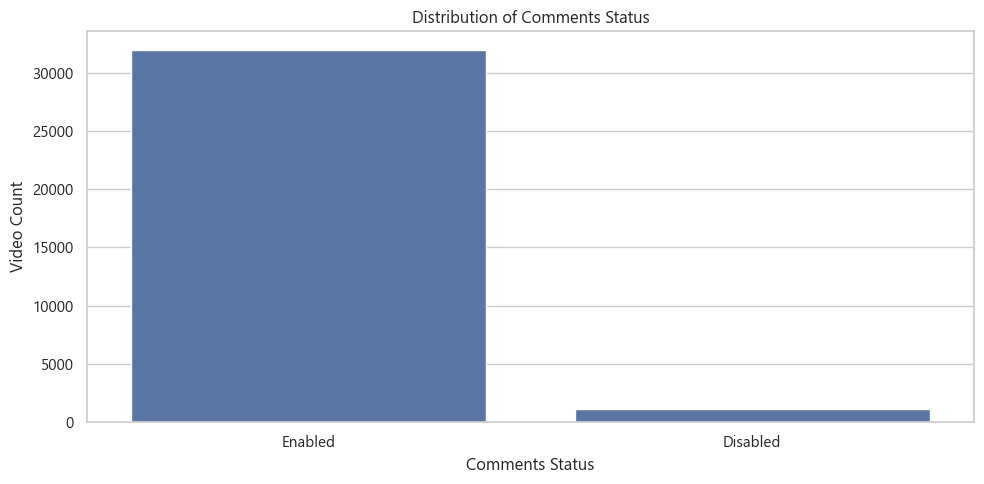

In [49]:
plt.figure()
sns.countplot(data=df, x="comments_status", order=["Enabled", "Disabled"])
plt.title("Distribution of Comments Status")
plt.xlabel("Comments Status")
plt.ylabel("Video Count")
plt.tight_layout()
plt.savefig("../images/comments_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [50]:
comments_status_pct = df["comments_status"].value_counts(normalize=True).mul(100).round(2)
enabled_pct = comments_status_pct["Enabled"]

print(f"{enabled_pct:.2f}% of trending videos have comments enabled.")


96.66% of trending videos have comments enabled.


## Ratings Status: Are Likes and Dislikes Visible?

Checking how many trending videos keep like/dislike counts visible.

A count plot is appropriate because `ratings_status` is a categorical variable with two groups.
This helps us compare whether most trending videos allow likes/dislikes or restrict rating activity.


In [51]:
df["ratings_status"] = df["ratings_disabled"].map({True: "Disabled", False: "Enabled"})
ratings_status_counts = df["ratings_status"].value_counts()
ratings_status_counts


ratings_status
Enabled     32345
Disabled      711
Name: count, dtype: int64

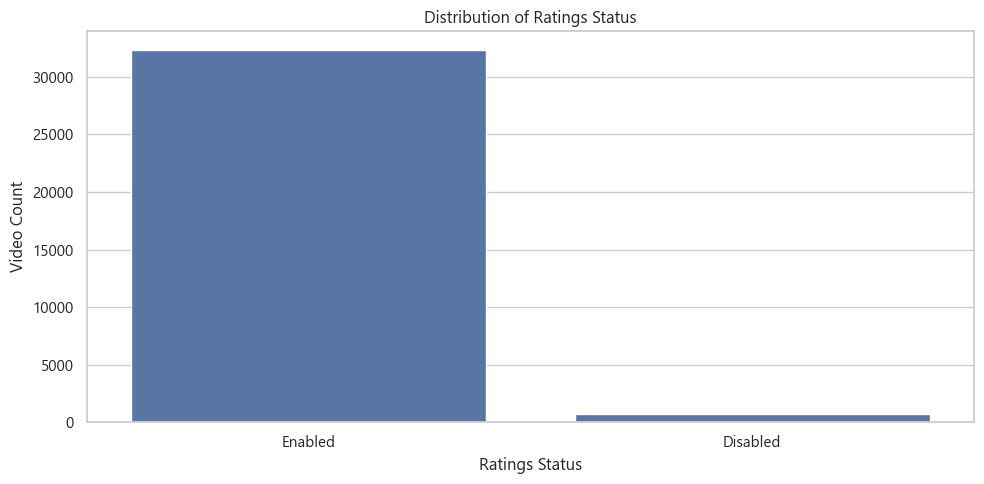

In [52]:
plt.figure()
sns.countplot(data=df, x="ratings_status", order=["Enabled", "Disabled"])
plt.title("Distribution of Ratings Status")
plt.xlabel("Ratings Status")
plt.ylabel("Video Count")
plt.tight_layout()
plt.savefig("../images/ratings_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [53]:
ratings_status_pct = df["ratings_status"].value_counts(normalize=True).mul(100).round(2)
enabled_pct = ratings_status_pct["Enabled"]

print(f"{enabled_pct:.2f}% of trending videos have ratings enabled.")


97.85% of trending videos have ratings enabled.


## Tag Usage Level: How Many Tags Do Trending Videos Use?

Checking if trending videos use few tags, medium tags, or heavy tags.

A count plot is appropriate because `tag_use_level` is a categorical variable with grouped labels.
This helps compare whether trending videos more often use no tags, a few tags, a medium number of tags, or many tags.


In [54]:
tag_order = ["No Tags", "Low Tag Use", "Medium Tag Use", "High Tag Use"]
tag_counts = df["tag_use_level"].value_counts()
print(tag_counts)


tag_use_level
High Tag use      21099
Medium Tag use     9244
Low Tag use        2713
Name: count, dtype: int64


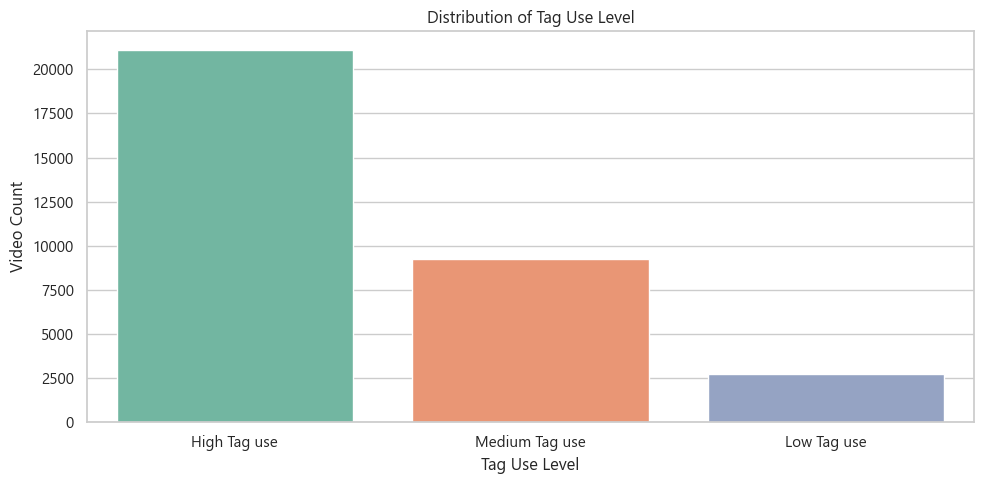

In [55]:
sns.countplot(data=df,x='tag_use_level',palette='Set2')
plt.title("Distribution of Tag Use Level")
plt.xlabel("Tag Use Level")
plt.ylabel("Video Count")
plt.xticks()
plt.tight_layout()
plt.savefig("../images/tag_use_level_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [56]:
tag_pct = df["tag_use_level"].value_counts(normalize=True).mul(100).round(2)
top_tag_group = tag_counts.idxmax()
top_tag_pct = tag_pct[top_tag_group]

print(f"{top_tag_group} is the most common tag pattern, covering {top_tag_pct:.2f}% of trending videos.")


High Tag use is the most common tag pattern, covering 63.83% of trending videos.


## Like Rate: Percentage of Viewers Who Leave a Like

Checking the ratio of likes to views (like conversion rate).

A histogram is appropriate because `like_rate` is a numeric continuous variable. 
This helps us see the typical engagement ratio for a trending video, showing whether most videos get similar like ratios or if a few are exceptionally highly liked.


count   33,056.00
mean         0.02
std          0.03
min          0.00
25%          0.00
50%          0.01
75%          0.03
max          0.38
Name: like_rate, dtype: float64


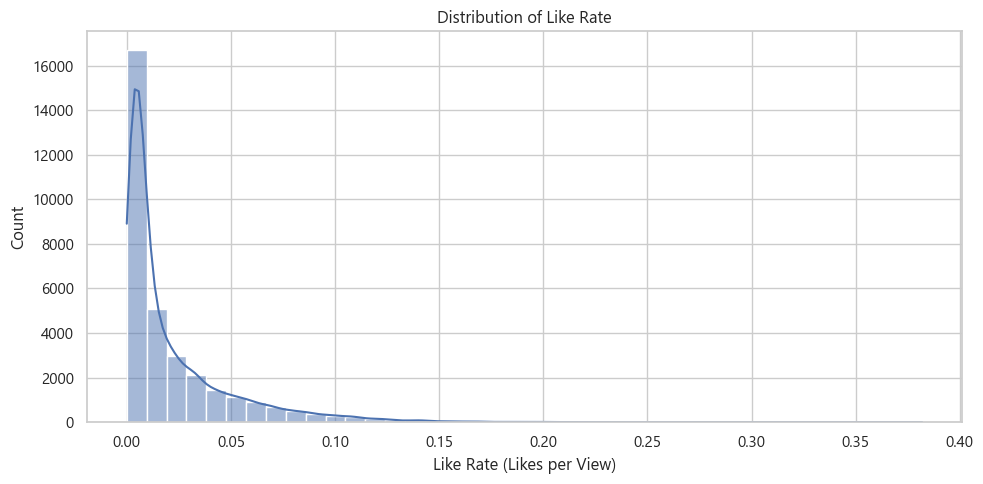

In [57]:
like_rate_summary = df["like_rate"].describe()

print(like_rate_summary)
sns.histplot(df["like_rate"], bins=40, kde=True,palette='Set2')
plt.title("Distribution of Like Rate")
plt.xlabel("Like Rate (Likes per View)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/like_rate_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [58]:
like_rate_median = df["like_rate"].median()
like_rate_q3 = df["like_rate"].quantile(0.75)

print(f"The median like rate is {like_rate_median:.4f}, meaning a typical trending video gets about {(like_rate_median * 100):.2f} likes per 100 views.")


The median like rate is 0.0093, meaning a typical trending video gets about 0.93 likes per 100 views.


# Bivariate Analysis: Comparing Two Metrics

In this section, we compare two variables at a time to find relationships.
Each comparison includes a chart and


comments_status
Disabled   424,690.00
Enabled    884,955.00
Name: views, dtype: float64


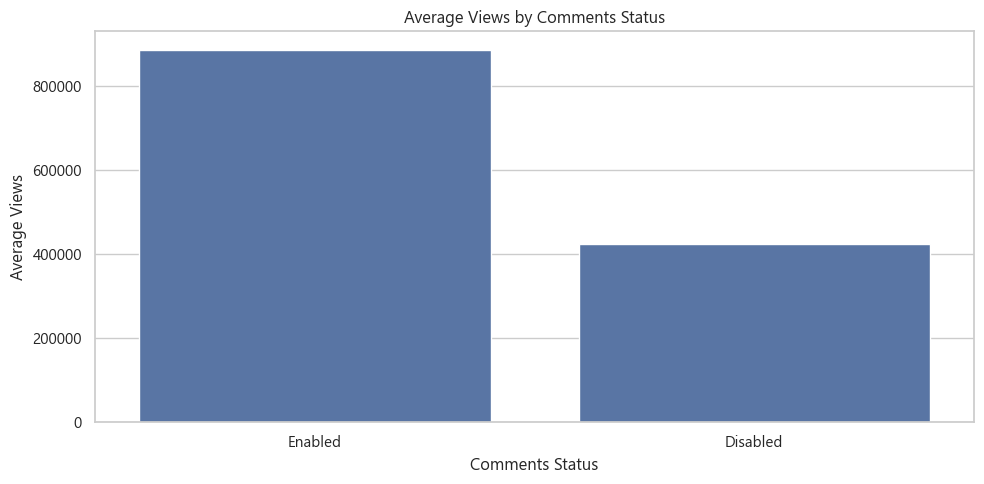

In [59]:
# 8.1 Views by Comments Status
views_by_comments = df.groupby("comments_status")["views"].mean().round(0)
print(views_by_comments)

plt.figure()
sns.barplot(data=df, x="comments_status", y="views", estimator="mean", ci=None, order=["Enabled", "Disabled"])
plt.title("Average Views by Comments Status")
plt.xlabel("Comments Status")
plt.ylabel("Average Views")
plt.tight_layout()
plt.savefig("../images/views_by_comments_status.png", dpi=300, bbox_inches="tight")
plt.show()


In [60]:
enabled_views = views_by_comments["Enabled"]
disabled_views = views_by_comments["Disabled"]
diff_pct = ((enabled_views - disabled_views) / disabled_views * 100).round(2)

print(f"Videos with comments enabled receive {diff_pct}% more average views than videos with comments disabled.")


Videos with comments enabled receive 108.38% more average views than videos with comments disabled.


trend_speed_band
Same Day             197,378.00
1 to 3 Days          625,476.00
4 to 7 Days        2,606,171.00
More than 7 Days   4,122,872.00
Name: views, dtype: float64


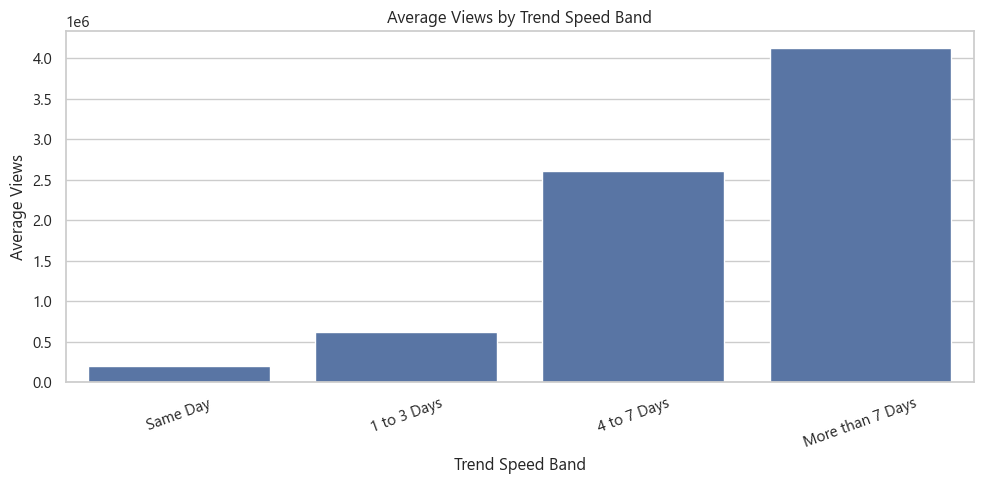

In [61]:
# 8.2 Views by Trend Speed Band
views_by_speed = df.groupby("trend_speed_band", observed=False)["views"].mean().reindex(
    ["Same Day", "1 to 3 Days", "4 to 7 Days", "More than 7 Days"]
).round(0)

print(views_by_speed)

plt.figure()
sns.barplot(data=df, x="trend_speed_band", y="views", estimator="mean", ci=None,
            order=["Same Day", "1 to 3 Days", "4 to 7 Days", "More than 7 Days"])
plt.title("Average Views by Trend Speed Band")
plt.xlabel("Trend Speed Band")
plt.ylabel("Average Views")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../images/views_by_trend_speed.png", dpi=300, bbox_inches="tight")
plt.show()


In [62]:
top_speed = views_by_speed.idxmax()
top_speed_views = views_by_speed.max()

print(f"Videos in the '{top_speed}' band have the highest average views at {top_speed_views:,.0f}.")


Videos in the 'More than 7 Days' band have the highest average views at 4,122,872.


In [63]:
top_speed = views_by_speed.idxmax()
top_speed_views = views_by_speed.max()

print(f"Videos in the '{top_speed}' band have the highest average views at {top_speed_views:,.0f}.")


Videos in the 'More than 7 Days' band have the highest average views at 4,122,872.


In [64]:
"""top_tag = views_by_tag.idxmax()
top_tag_views = views_by_tag.max()
low_tag_views = views_by_tag["No Tags"]

print(f"'{top_tag}' videos average {top_tag_views:,.0f} views, while 'No Tags' videos average {low_tag_views:,.0f} views.")"""


'top_tag = views_by_tag.idxmax()\ntop_tag_views = views_by_tag.max()\nlow_tag_views = views_by_tag["No Tags"]\n\nprint(f"\'{top_tag}\' videos average {top_tag_views:,.0f} views, while \'No Tags\' videos average {low_tag_views:,.0f} views.")'

views_quartile
Q1    1,310.00
Q2    3,383.00
Q3    9,288.00
Q4   73,645.00
Name: likes, dtype: float64


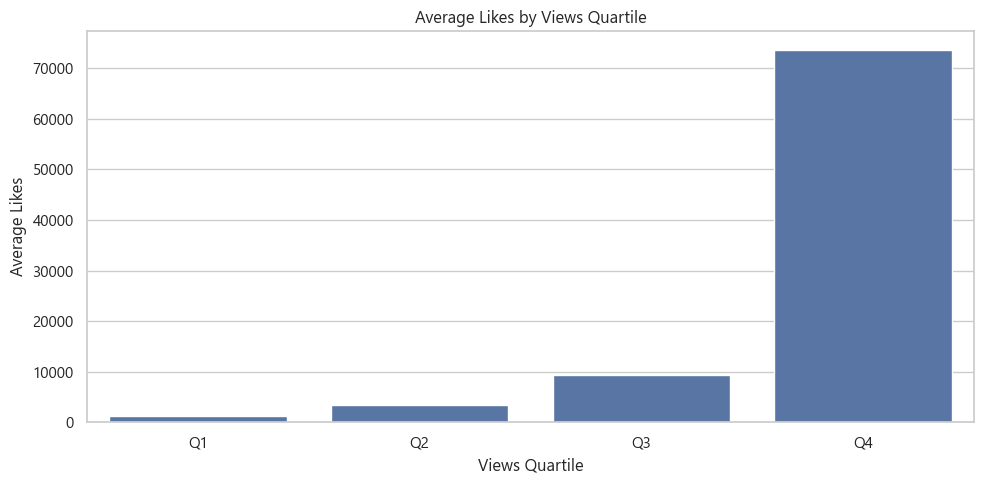

In [65]:
# 8.4 Likes by Views Quartile
likes_by_quartile = df.groupby("views_quartile", observed=False)["likes"].mean().round(0)

print(likes_by_quartile)

plt.figure()
sns.barplot(data=df, x="views_quartile", y="likes", estimator="mean", ci=None,
            order=["Q1", "Q2", "Q3", "Q4"])
plt.title("Average Likes by Views Quartile")
plt.xlabel("Views Quartile")
plt.ylabel("Average Likes")
plt.tight_layout()
plt.savefig("../images/likes_by_views_quartile.png", dpi=300, bbox_inches="tight")
plt.show()


In [66]:
q4_likes = likes_by_quartile["Q4"]
q1_likes = likes_by_quartile["Q1"]
likes_diff = ((q4_likes - q1_likes) / q1_likes * 100).round(2)

print(f"Q4 (highest views) videos receive {likes_diff}% more likes on average compared to Q1 (lowest views) videos.")


Q4 (highest views) videos receive 5521.76% more likes on average compared to Q1 (lowest views) videos.


publish_weekday
Monday      1,060,545.00
Tuesday       932,362.00
Wednesday     994,564.00
Thursday      899,833.00
Friday        794,982.00
Saturday      697,253.00
Sunday        707,179.00
Name: views, dtype: float64


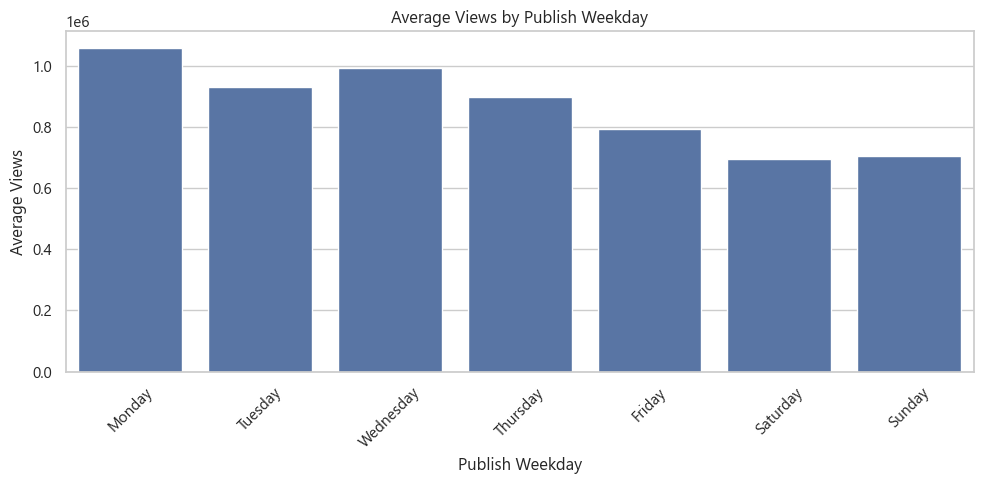

In [67]:
# 8.5 Views by Publish Weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
views_by_weekday = df.groupby("publish_weekday")["views"].mean().reindex(weekday_order).round(0)

print(views_by_weekday)

plt.figure()
sns.barplot(data=df, x="publish_weekday", y="views", estimator="mean", ci=None, order=weekday_order)
plt.title("Average Views by Publish Weekday")
plt.xlabel("Publish Weekday")
plt.ylabel("Average Views")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/views_by_weekday.png", dpi=300, bbox_inches="tight")
plt.show()


In [68]:
best_day = views_by_weekday.idxmax()
best_day_views = views_by_weekday.max()
worst_day = views_by_weekday.idxmin()
worst_day_views = views_by_weekday.min()

print(f"{best_day} has the highest average views ({best_day_views:,.0f}) while {worst_day} has the lowest ({worst_day_views:,.0f}).")


Monday has the highest average views (1,060,545) while Saturday has the lowest (697,253).


# Multivariate Analysis: Combining Multiple Metrics
.
We use correlation heatmaps, pivot tables, and pairplots to capture multi-dimensional patterns.


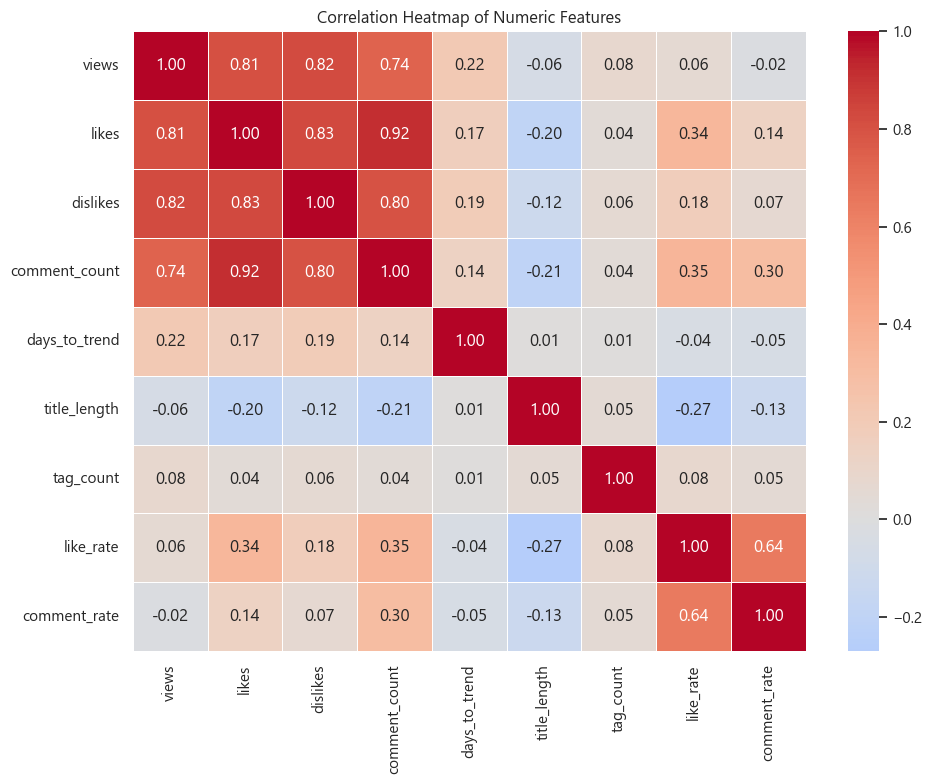

In [69]:
# 9.1 Correlation Heatmap
numeric_cols = ["views", "likes", "dislikes", "comment_count", "days_to_trend",
                "title_length", "tag_count", "like_rate", "comment_rate"]

corr_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [70]:
top_corr = (
    corr_matrix.unstack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
)
top_corr = top_corr[top_corr["Feature_1"] != top_corr["Feature_2"]]
top_corr = top_corr.drop_duplicates(subset=["Correlation"])
top_corr = top_corr.sort_values("Correlation", ascending=False).head(5)

print("Top 5 strongest correlations:")
for _, row in top_corr.iterrows():
    print(f"{row['Feature_1']} & {row['Feature_2']}**: **{row['Correlation']}")


Top 5 strongest correlations:
likes & comment_count**: **0.92
likes & dislikes**: **0.83
views & dislikes**: **0.82
views & likes**: **0.81
dislikes & comment_count**: **0.8


trend_speed_band   Same Day  1 to 3 Days  4 to 7 Days  More than 7 Days
tag_use_level                                                          
High Tag use     211,739.86   704,089.92 2,784,319.34      4,320,549.96
Low Tag use      193,497.86   487,713.62 1,704,829.20        288,844.38
Medium Tag use   166,104.36   491,208.23 2,344,116.87      5,954,072.09


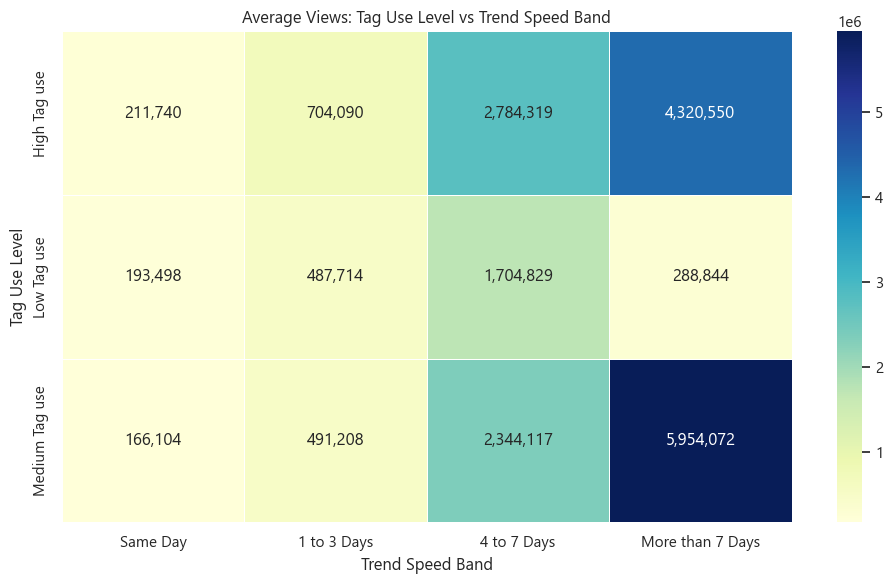

In [71]:
# 9.2 Pivot Table: Avg Views by Tag Use Level and Trend Speed Band
pivot = df.pivot_table(
    values="views",
    index="tag_use_level",
    columns="trend_speed_band",
    aggfunc="mean",
    observed=False
)
print(pivot)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Average Views: Tag Use Level vs Trend Speed Band")
plt.xlabel("Trend Speed Band")
plt.ylabel("Tag Use Level")
plt.tight_layout()
plt.savefig("../images/pivot_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [72]:
max_cell = pivot.stack().idxmax()
max_value = pivot.stack().max()

print(f"Highest average views ({max_value:,.0f}) are found in '{max_cell[0]}' videos that trended in '{max_cell[1]}'.")


Highest average views (5,954,072) are found in 'Medium Tag use' videos that trended in 'More than 7 Days'.


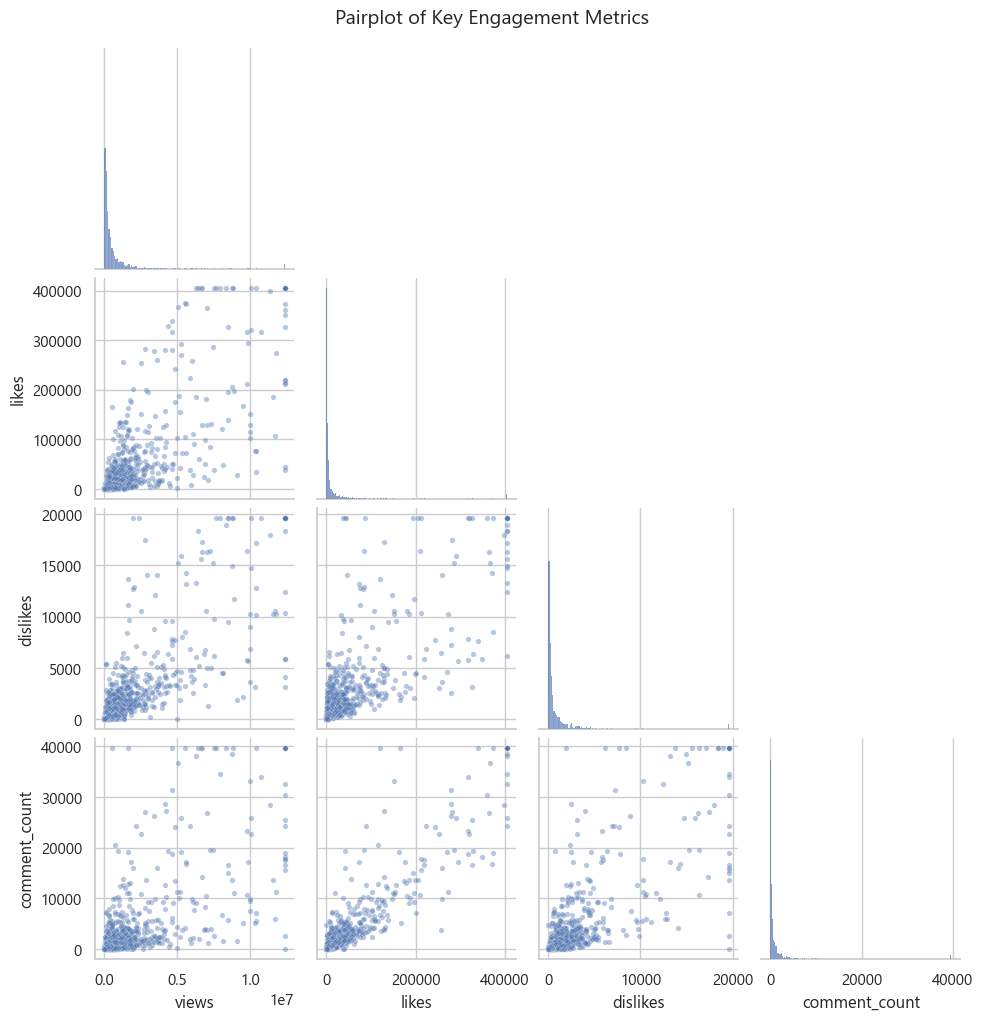

In [73]:
# 9.3 Pairplot of Key Engagement Metrics
pair_cols = ["views", "likes", "dislikes", "comment_count"]

sample_df = df[pair_cols].sample(2000, random_state=42)

sns.pairplot(sample_df, corner=True, plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pairplot of Key Engagement Metrics", y=1.02)
plt.savefig("../images/pairplot.png", dpi=300, bbox_inches="tight")
plt.show()


In [74]:
print("Views, likes, dislikes, and comment count show strong positive linear relationships, confirming that higher-view videos consistently attract more engagement across all metrics.")


Views, likes, dislikes, and comment count show strong positive linear relationships, confirming that higher-view videos consistently attract more engagement across all metrics.


# Key Insights & Takeaways

- **4,263 duplicate rows were removed, reducing the working dataset to 33,089 cleaned records.**
- **Only `description` had missing values (561 rows), and those rows were preserved by filling a placeholder value.**
- **The median trending time is 2 days, and 75% of videos reach trending within 3 days.**
- **Trending speed is highly concentrated early, but a few videos take much longer, with a maximum of 221 days.**
- **Friday has the highest upload count with 5,573 videos (16.84%), while Sunday has the lowest with 3,558 videos (10.75%).**


- **Comment activity is uneven: the median is 298 comments, while 75% of videos receive 1,169 comments or fewer.**
- **Views are highly imbalanced across performance groups: Q4 videos average 2.83M views versus 63.49K in Q1, a gap of about 44.6x.**
- **High Tag Use is the most common tag pattern among trending videos, while Medium Tag Use is less common.**
- **97.85% of trending videos have ratings enabled, making open rating access the standard pattern.**
- **Views, likes, dislikes, and comment counts move positively together, showing that higher reach usually brings higher engagement.**


# Recommendations for Content Creators & Brands

- **Prioritize the first 48 to 72 hours after upload, because most trending videos appear within 3 days.**
- **Test Thursday, Friday, and Saturday uploads first, since these days show stronger trending upload activity.**
- **Keep ratings enabled by default, because this is the dominant pattern among trending videos.**
- **Use complete metadata on every upload: a clear title, a filled description, and relevant tags.**
- **Use richer tag coverage where relevant, but avoid adding random or misleading keywords.**
- **Track `like_rate` and `comment_rate` along with views, because raw views alone do not show engagement quality.**
- **Encourage early discussion with pinned comments, questions, or call-to-actions to improve interaction.**
- **Review very late-trending videos separately, because they may follow a different discovery pattern than fast-trending videos.**
- **Set channel targets using view quartiles, so performance is judged against realistic bands rather than rare viral outliers.**
